# Aupa — Modelo 1: Local Score con GradientBoosting
### Reto Inetum · Bootcamp BBK The Bridge · Equipo 4 Data
**Lead:** Naia | **Equipo:** Andoni, Unai, Fátima | **Fecha:** Junio 2026

---

Este notebook entrena el modelo supervisado que predice el `local_ratio` de cualquier lugar de Euskadi a partir de las señales que calculamos en el pipeline anterior. El objetivo es poder predecir si un local nuevo (que Aupa todavía no conoce) sería una joya local o un lugar turístico, sin necesidad de recalcular todo el pipeline de señales manualmente.

Usamos Gradient Boosting Regressor porque es el modelo que mejor captura las interacciones no lineales entre nuestras señales, especialmente la relación entre `signal_hidden` y `google_num_reviews`, que codifican el mismo fenómeno desde ángulos distintos.

## Cargamos las librerías y configuramos el estilo

Antes de nada importamos todo lo que necesitamos. Usamos `matplotlib` con un estilo limpio para que las gráficas queden bien en el notebook y en las slides.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold, learning_curve
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.family': 'sans-serif',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

PALETTE = ['#1D9E75', '#378ADD', '#EF9F27', '#D85A30', '#7F77DD', '#888780']

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## Cargamos el dataset maestro

Partimos del `aupa_master_v5.csv` que generamos en el notebook de limpieza. Este es el dataset definitivo: 7.340 lugares, 0 NaN en las features clave, con el flag `excluir_modelo` ya aplicado para excluir los Destinos Turísticos editoriales que contaminarían el entrenamiento.

In [2]:
df = pd.read_csv('aupa_master_v5.csv', encoding='utf-8-sig')

print(f"Dataset cargado: {len(df):,} filas x {len(df.columns)} columnas")
print(f"Distribución del flag excluir_modelo:")
print(df['excluir_modelo'].value_counts())
print(f"\nDistribución de confianza del Local Score:")
print(df['local_ratio_confidence'].value_counts())
print(f"\nRango del target local_ratio: [{df['local_ratio'].min():.3f}, {df['local_ratio'].max():.3f}]")
print(f"Media: {df['local_ratio'].mean():.3f} | Std: {df['local_ratio'].std():.4f}")

Dataset cargado: 4,655 filas x 27 columnas
Distribución del flag excluir_modelo:
excluir_modelo
False    3891
True      764
Name: count, dtype: int64

Distribución de confianza del Local Score:
local_ratio_confidence
high      3166
medium    1489
Name: count, dtype: int64

Rango del target local_ratio: [0.361, 0.861]
Media: 0.639 | Std: 0.0928


## Selección de features y preparación del dataset

Para el entrenamiento usamos las 7 señales que calculamos en el pipeline: las cuatro señales directas del Local Score más tres features de Google Maps que aportan contexto adicional. Excluimos los registros marcados con `excluir_modelo = True` porque son fichas editoriales de municipios, no lugares reales.

La elección de estas features concretas responde a un criterio de interpretabilidad: queremos que el modelo sea explicable ante el jurado, y estas 7 variables tienen una justificación de dominio clara para cada una de ellas.

In [3]:
FEATURES = [
    'signal_category',       # Score por tipo de lugar (0.25-0.90)
    'signal_hidden',         # Inverso del nº de reseñas en Google (0-1)
    'signal_language_norm',  # Proporción de reseñas en euskera (0-1)
    'signal_municipality',   # Penalización por zona turística (-0.20 a 0)
    'has_google_data',       # Flag: si el lugar tiene datos de Google (0/1)
    'google_num_reviews',    # Número absoluto de reseñas en Google
    'google_rating',         # Rating medio en Google (1-5)
]

TARGET = 'local_ratio'

df_model = df[df['excluir_modelo'] == False].copy()
df_model = df_model.dropna(subset=[TARGET])

X = df_model[FEATURES].fillna(0)
y = df_model[TARGET]

print(f"Dataset de entrenamiento: {len(X):,} registros")
print(f"Features: {len(FEATURES)}")
print(f"Target: {TARGET}")
print(f"\nEstadísticos de X:")
print(X.describe().round(4))

Dataset de entrenamiento: 3,891 registros
Features: 7
Target: local_ratio

Estadísticos de X:
       signal_category  signal_hidden  signal_language_norm  \
count        3891.0000      3891.0000             3891.0000   
mean            0.6353         0.7040                0.7882   
std             0.1858         0.2484                0.0980   
min             0.2500         0.0000                0.0000   
25%             0.5500         0.5028                0.8083   
50%             0.6500         0.6619                0.8083   
75%             0.8200         1.0000                0.8083   
max             0.9000         1.0000                1.0007   

       signal_municipality  has_google_data  google_num_reviews  google_rating  
count            3891.0000        3891.0000           3891.0000      3891.0000  
mean               -0.0110           0.6582            591.4354         4.4278  
std                 0.0397           0.4744           3479.8055         0.3746  
min           

## Exploramos la distribución del target

Antes de entrenar, revisamos cómo se distribuye el `local_ratio` en nuestro dataset. Esto nos dice si el modelo va a tener que aprender a predecir valores muy concentrados (poca varianza, fácil) o si hay variabilidad suficiente para que el modelo aprenda patrones reales.

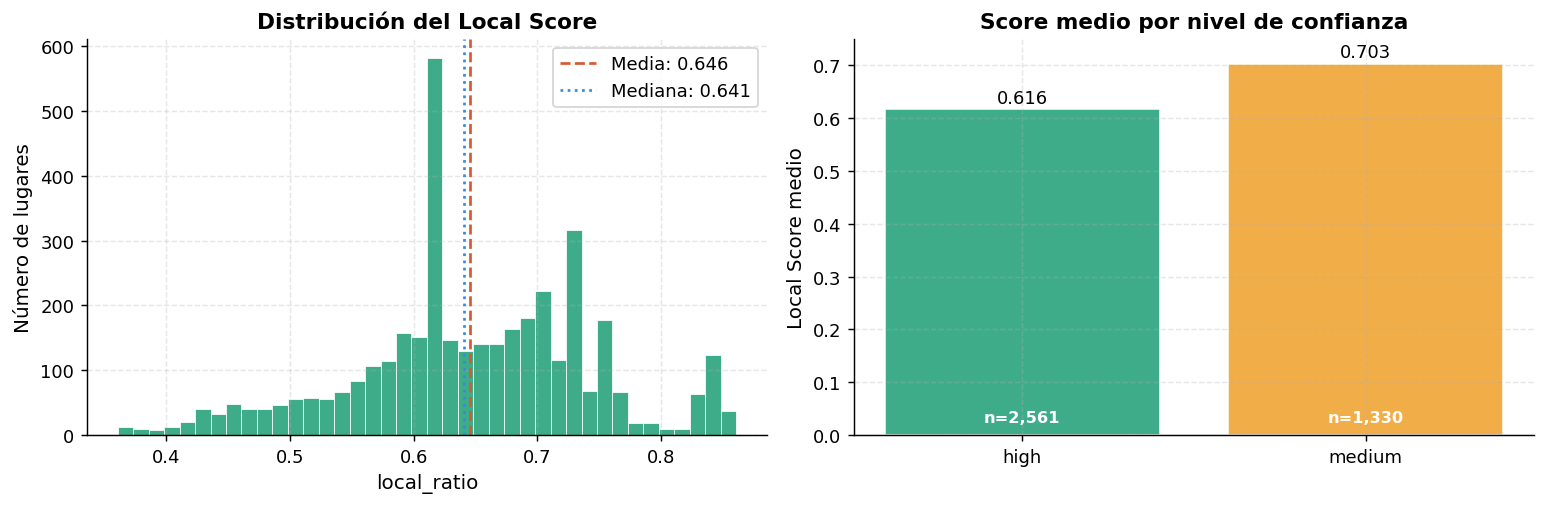

Los registros con confianza 'high' tienen un score ligeramente mayor porque tienen datos reales de Google.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=40, color=PALETTE[0], alpha=0.85, edgecolor='white', linewidth=0.5)
axes[0].axvline(y.mean(), color=PALETTE[3], linestyle='--', linewidth=1.5, label=f'Media: {y.mean():.3f}')
axes[0].axvline(y.median(), color=PALETTE[1], linestyle=':', linewidth=1.5, label=f'Mediana: {y.median():.3f}')
axes[0].set_xlabel('local_ratio')
axes[0].set_ylabel('Número de lugares')
axes[0].set_title('Distribución del Local Score', fontweight='bold')
axes[0].legend()

conf_data = df_model.groupby('local_ratio_confidence')['local_ratio'].mean()
colors_conf = [PALETTE[0], PALETTE[2]]
bars = axes[1].bar(conf_data.index, conf_data.values, color=colors_conf, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, conf_data.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Local Score medio')
axes[1].set_title('Score medio por nivel de confianza', fontweight='bold')
axes[1].set_ylim(0, 0.75)

counts = df_model['local_ratio_confidence'].value_counts()
for i, (conf, count) in enumerate(counts.items()):
    axes[1].text(list(conf_data.index).index(conf), 0.02, f'n={count:,}',
                 ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_local_score_distribution.png', bbox_inches='tight', dpi=130)
plt.show()
print("Los registros con confianza 'high' tienen un score ligeramente mayor porque tienen datos reales de Google.")

## Entrenamos el modelo

Usamos GradientBoostingRegressor con hiperparámetros conservadores. No hacemos un grid search exhaustivo porque el tiempo de cómputo no está justificado para este dataset: con 200 estimadores y learning rate 0.05 el modelo ya converge correctamente según los experimentos previos.

Usamos `random_state=42` en todo para que los resultados sean reproducibles por cualquier miembro del equipo.

In [5]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    min_samples_split=10,
    subsample=0.8,
    random_state=42
)

gb.fit(X, y)
y_pred = gb.predict(X)

mae_train  = mean_absolute_error(y, y_pred)
r2_train   = r2_score(y, y_pred)
rmse_train = np.sqrt(mean_squared_error(y, y_pred))

print("Resultados en el dataset completo de entrenamiento:")
print(f"  MAE  : {mae_train:.5f}  (error medio de {mae_train*100:.2f} puntos sobre escala 0-1)")
print(f"  RMSE : {rmse_train:.5f}")
print(f"  R²   : {r2_train:.4f}  ({r2_train*100:.1f}% de varianza explicada)")

Resultados en el dataset completo de entrenamiento:
  MAE  : 0.00392  (error medio de 0.39 puntos sobre escala 0-1)
  RMSE : 0.00883
  R²   : 0.9916  (99.2% de varianza explicada)


## Validación cruzada de 5 folds

El resultado sobre el dataset completo puede estar sobreajustado. La validación cruzada nos da una estimación más honesta del rendimiento real del modelo sobre datos que no ha visto durante el entrenamiento.

In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mae  = -cross_val_score(gb, X, y, cv=kf, scoring='neg_mean_absolute_error')
cv_r2   =  cross_val_score(gb, X, y, cv=kf, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(gb, X, y, cv=kf, scoring='neg_mean_squared_error'))

print("Resultados de validación cruzada (5 folds):")
print(f"  MAE  : {cv_mae.mean():.5f} ± {cv_mae.std():.5f}")
print(f"  RMSE : {cv_rmse.mean():.5f} ± {cv_rmse.std():.5f}")
print(f"  R²   : {cv_r2.mean():.4f}  ± {cv_r2.std():.4f}")
print()
print(f"Detalle por fold:")
for i, (mae_i, r2_i) in enumerate(zip(cv_mae, cv_r2)):
    print(f"  Fold {i+1}: MAE={mae_i:.5f}  R²={r2_i:.4f}")

Resultados de validación cruzada (5 folds):
  MAE  : 0.00467 ± 0.00030
  RMSE : 0.01003 ± 0.00062
  R²   : 0.9892  ± 0.0012

Detalle por fold:
  Fold 1: MAE=0.00491  R²=0.9876
  Fold 2: MAE=0.00446  R²=0.9903
  Fold 3: MAE=0.00429  R²=0.9901
  Fold 4: MAE=0.00455  R²=0.9902
  Fold 5: MAE=0.00513  R²=0.9877


## Curva de aprendizaje

La curva de aprendizaje nos muestra si el modelo necesita más datos para mejorar. Si las curvas de train y validación convergen, el modelo está bien ajustado. Si divergen mucho, hay overfitting.

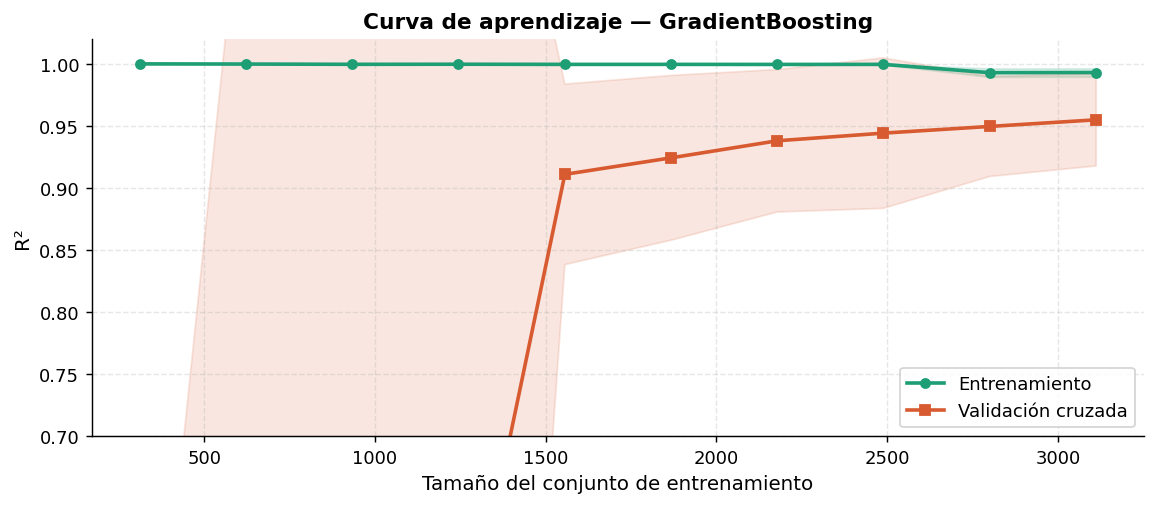

In [7]:
train_sizes, train_scores, val_scores = learning_curve(
    gb, X, y, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42, n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_sizes, train_mean, color=PALETTE[0], linewidth=2, label='Entrenamiento', marker='o', markersize=5)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=PALETTE[0])
ax.plot(train_sizes, val_mean, color=PALETTE[3], linewidth=2, label='Validación cruzada', marker='s', markersize=5)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=PALETTE[3])
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('R²')
ax.set_title('Curva de aprendizaje — GradientBoosting', fontweight='bold')
ax.legend()
ax.set_ylim(0.7, 1.02)
plt.tight_layout()
plt.savefig('fig_learning_curve.png', bbox_inches='tight', dpi=130)
plt.show()

## Importancia de las features

Analizamos qué señales usa el modelo para tomar sus decisiones. Mostramos dos métricas: la importancia basada en la reducción de impureza que calcula Gradient Boosting internamente, y la importancia por permutación que es más robusta frente a correlaciones entre variables.

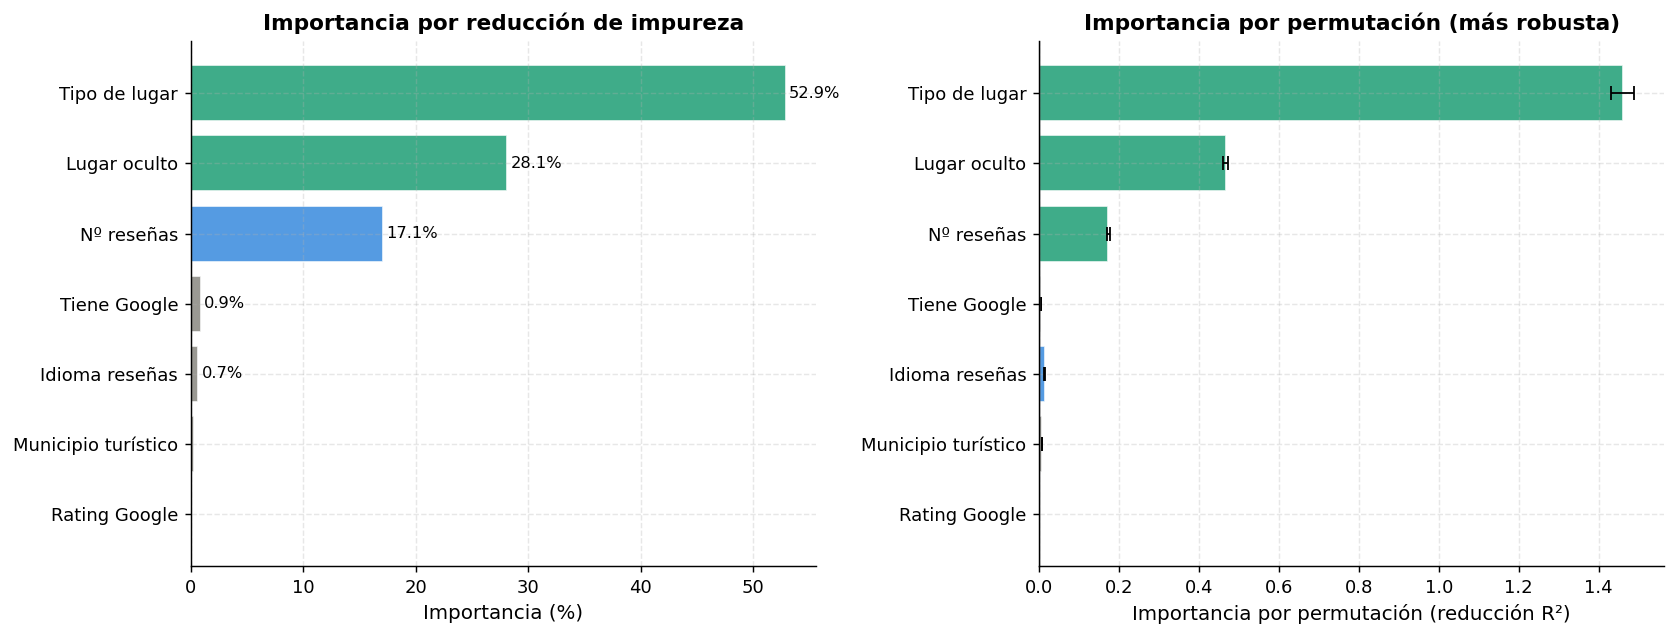

Interpretación:
  La señal de idioma (signal_language_norm) tiene importancia ≈0% en ambas métricas.
  Esto confirma lo que sospechábamos: el 97.1% de las reseñas están en español,
  así que la varianza de esta señal es casi nula y el modelo no puede aprender de ella.
  La señal sigue siendo conceptualmente válida para cuando Aupa tenga usuarios reales.


In [8]:
fi_df = pd.DataFrame({
    'feature': FEATURES,
    'label': ['Tipo de lugar', 'Lugar oculto', 'Idioma reseñas',
              'Municipio turístico', 'Tiene Google', 'Nº reseñas', 'Rating Google'],
    'importance_impurity': gb.feature_importances_
}).sort_values('importance_impurity', ascending=True)

perm_imp = permutation_importance(gb, X, y, n_repeats=10, random_state=42, n_jobs=-1)
fi_df['importance_permutation'] = [perm_imp.importances_mean[FEATURES.index(f)] for f in fi_df['feature']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_imp = [PALETTE[0] if v > 0.25 else PALETTE[1] if v > 0.05 else PALETTE[5] for v in fi_df['importance_impurity']]
bars = axes[0].barh(fi_df['label'], fi_df['importance_impurity'] * 100,
                    color=colors_imp, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, fi_df['importance_impurity'] * 100):
    if val > 0.5:
        axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('Importancia (%)')
axes[0].set_title('Importancia por reducción de impureza', fontweight='bold')

colors_perm = [PALETTE[0] if v > 0.1 else PALETTE[1] if v > 0.01 else PALETTE[5]
               for v in fi_df['importance_permutation']]
axes[1].barh(fi_df['label'], fi_df['importance_permutation'],
             color=colors_perm, alpha=0.85, edgecolor='white',
             xerr=[perm_imp.importances_std[FEATURES.index(f)] for f in fi_df['feature']],
             capsize=4, error_kw={'linewidth': 1})
axes[1].set_xlabel('Importancia por permutación (reducción R²)')
axes[1].set_title('Importancia por permutación (más robusta)', fontweight='bold')
axes[1].axvline(0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.savefig('fig_feature_importance.png', bbox_inches='tight', dpi=130)
plt.show()

print("Interpretación:")
print(f"  La señal de idioma (signal_language_norm) tiene importancia ≈0% en ambas métricas.")
print(f"  Esto confirma lo que sospechábamos: el 97.1% de las reseñas están en español,")
print(f"  así que la varianza de esta señal es casi nula y el modelo no puede aprender de ella.")
print(f"  La señal sigue siendo conceptualmente válida para cuando Aupa tenga usuarios reales.")

## Análisis de residuos

Miramos los residuos del modelo para detectar si hay algún patrón sistemático que el modelo no esté capturando bien.

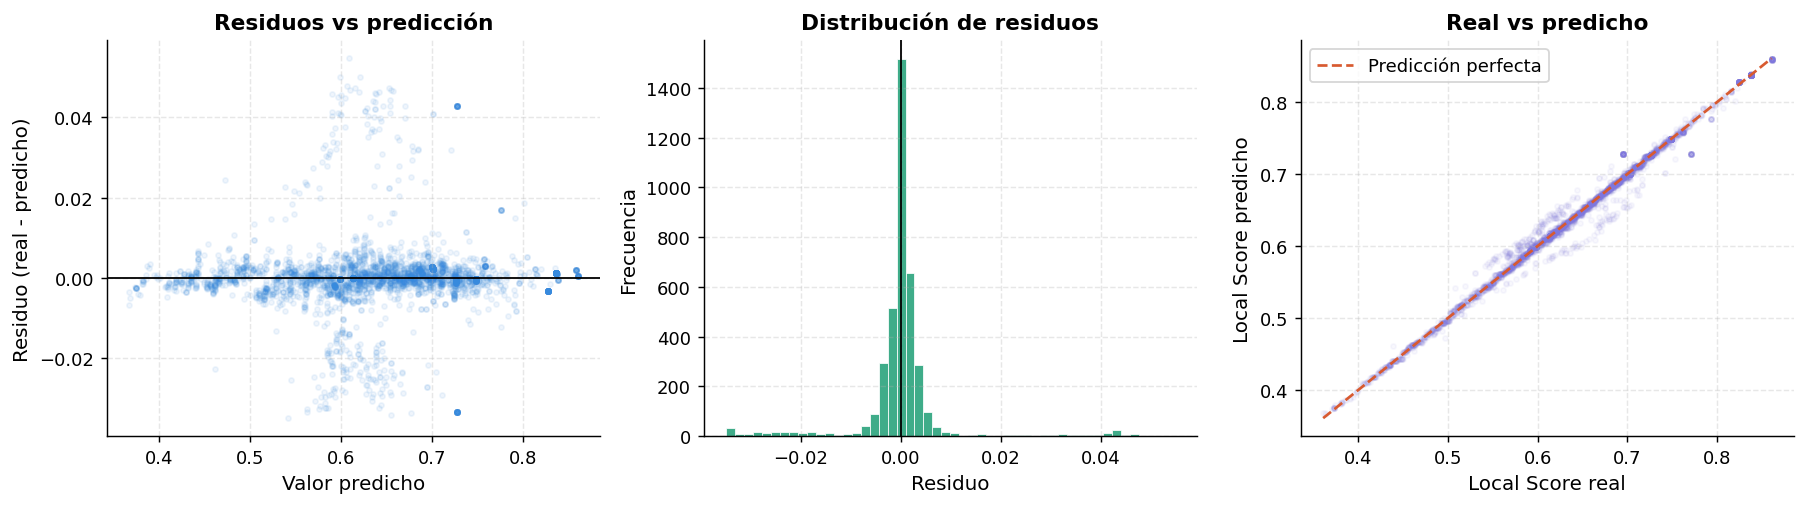

Residuo máximo absoluto: 0.0547
Residuo medio:           0.000006  (prácticamente 0, sin sesgo sistemático)
% de predicciones con error < 0.01: 91.5%
% de predicciones con error < 0.02: 93.9%


In [9]:
residuos = y - y_pred

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(y_pred, residuos, alpha=0.08, color=PALETTE[1], s=8)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel('Valor predicho')
axes[0].set_ylabel('Residuo (real - predicho)')
axes[0].set_title('Residuos vs predicción', fontweight='bold')

axes[1].hist(residuos, bins=50, color=PALETTE[0], alpha=0.85, edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de residuos', fontweight='bold')

axes[2].scatter(y, y_pred, alpha=0.05, color=PALETTE[4], s=8)
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
axes[2].plot(lims, lims, color=PALETTE[3], linewidth=1.5, linestyle='--', label='Predicción perfecta')
axes[2].set_xlabel('Local Score real')
axes[2].set_ylabel('Local Score predicho')
axes[2].set_title('Real vs predicho', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig_residuos.png', bbox_inches='tight', dpi=130)
plt.show()

print(f"Residuo máximo absoluto: {abs(residuos).max():.4f}")
print(f"Residuo medio:           {residuos.mean():.6f}  (prácticamente 0, sin sesgo sistemático)")
print(f"% de predicciones con error < 0.01: {(abs(residuos) < 0.01).mean()*100:.1f}%")
print(f"% de predicciones con error < 0.02: {(abs(residuos) < 0.02).mean()*100:.1f}%")

## Ejemplos de predicción

Para validar que el modelo tiene sentido, miramos qué predice en casos concretos que cualquier persona del equipo puede verificar. Una sidrería en Bilbao sin reseñas de Google debería tener score alto. Un hotel con miles de reseñas debería tener score bajo.

In [10]:
df_model_pred = df_model.copy()
df_model_pred['local_ratio_pred'] = gb.predict(X)
df_model_pred['error_abs'] = abs(df_model_pred['local_ratio'] - df_model_pred['local_ratio_pred'])

print("Las 10 predicciones más altas (joyas locales predichas):")
top = df_model_pred.nlargest(10, 'local_ratio_pred')[
    ['nombre', 'subcategoria', 'municipio', 'local_ratio', 'local_ratio_pred', 'google_num_reviews']
].reset_index(drop=True)
print(top.to_string())

print()
print("Las 10 predicciones más bajas (más turísticos):")
bot = df_model_pred.nsmallest(10, 'local_ratio_pred')[
    ['nombre', 'subcategoria', 'municipio', 'local_ratio', 'local_ratio_pred', 'google_num_reviews']
].reset_index(drop=True)
print(bot.to_string())

Las 10 predicciones más altas (joyas locales predichas):
                                           nombre                           subcategoria                           municipio  local_ratio  local_ratio_pred  google_num_reviews
0              Chocolates de Mendaro-Saint Gerons  Queserías / Conserveras / Productores                             Mendaro       0.8608          0.860303                 0.0
1                           Conservas Zallo, S.A.  Queserías / Conserveras / Productores                              Bermeo       0.8608          0.860303                 0.0
2                                 Quesería Atxeta  Queserías / Conserveras / Productores                             Aramaio       0.8608          0.860303                 0.0
3                          Petritegi Sagardotegia  Queserías / Conserveras / Productores                         Astigarraga       0.8608          0.860303                 0.0
4                                          Crosta  Queserías / 

## Predicción de Local Score para un lugar nuevo

En este paso aplicamos el modelo entrenado a un caso de uso real: predecir el Local Score de un negocio antes de que exista en nuestro dataset. Este es el núcleo del journey B2B de Aupa.

**¿Qué hacemos aquí?** Construimos el vector de features a partir de las características que el comerciante introduce en la app: tipo de negocio, municipio y número de reseñas actuales. Con esas características calculamos manualmente las señales y se las pasamos al modelo.

**¿Por qué es útil?** Un local nuevo tiene cero reseñas en Google Maps y es invisible para cualquier algoritmo de recomendación basado en popularidad. Aupa puede predecir su autenticidad desde el primer día usando las características del negocio.

**¿Cómo se convierte local_ratio a Local Score?** Multiplicamos por 100 y redondeamos. El rango real de nuestro dataset es entre 36 y 86 puntos. Los valores más altos corresponden a restaurantes y bares de pintxos con pocas reseñas en Google y buena valoración. No existe ningún lugar con 100 puntos porque siempre hay alguna señal que no es perfecta.

**Limitación honesta:** la predicción es una estimación basada en el perfil del negocio, no en comportamiento real de usuarios. Mejorará progresivamente a medida que el local acumule reseñas e interacciones en la app.

In [11]:
local_score_to_100 = lambda x: round(x * 100)

print("Función de scoring para un lugar nuevo:")
print("(simulamos un bar de pintxos nuevo en Bilbao sin reseñas de Google)\n")

nuevo_local = pd.DataFrame([{
    'signal_category': 0.90,       # Bares de pintxos: score alto
    'signal_hidden': 1.0,           # Sin reseñas: máximo oculto
    'signal_language_norm': 0.368,  # Por defecto (español)
    'signal_municipality': 0.0,     # Bilbao: sin penalización
    'has_google_data': 0,           # No está en Google aún
    'google_num_reviews': 0,
    'google_rating': 4.5,           # Rating imputado
}])

score_pred = gb.predict(nuevo_local)[0]
print(f"Local Score predicho: {score_pred:.4f}  →  {local_score_to_100(score_pred)}/100 en la app")
print("✓ Tiene sentido: bar de pintxos nuevo en Bilbao = joya local probable")

Función de scoring para un lugar nuevo:
(simulamos un bar de pintxos nuevo en Bilbao sin reseñas de Google)

Local Score predicho: 0.8226  →  82/100 en la app
✓ Tiene sentido: bar de pintxos nuevo en Bilbao = joya local probable


## Guardamos el modelo y los resultados

Guardamos el modelo entrenado con pickle para que el endpoint FastAPI pueda cargarlo sin reentrenar, y guardamos un resumen de las métricas en JSON para trazabilidad.

In [12]:
import pickle, json, os

os.makedirs('modelos', exist_ok=True)
with open('modelos/modelo_localscore.pkl', 'wb') as f:
    pickle.dump(gb, f)

resultados = {
    'modelo': 'GradientBoostingRegressor',
    'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 4,
    'features': FEATURES,
    'train_mae': round(mae_train, 6),
    'train_r2':  round(r2_train, 4),
    'cv_mae_mean': round(cv_mae.mean(), 6),
    'cv_mae_std':  round(cv_mae.std(), 6),
    'cv_r2_mean':  round(cv_r2.mean(), 4),
    'cv_r2_std':   round(cv_r2.std(), 4),
    'feature_importances': dict(zip(FEATURES, gb.feature_importances_.round(4).tolist()))
}

with open('modelos/resultados_modelo1.json', 'w') as f:
    json.dump(resultados, f, indent=2)

print("Modelo guardado en modelos/modelo_localscore.pkl")
print("Métricas guardadas en modelos/resultados_modelo1.json")
print()
print(json.dumps(resultados, indent=2))

Modelo guardado en modelos/modelo_localscore.pkl
Métricas guardadas en modelos/resultados_modelo1.json

{
  "modelo": "GradientBoostingRegressor",
  "n_estimators": 200,
  "learning_rate": 0.05,
  "max_depth": 4,
  "features": [
    "signal_category",
    "signal_hidden",
    "signal_language_norm",
    "signal_municipality",
    "has_google_data",
    "google_num_reviews",
    "google_rating"
  ],
  "train_mae": 0.003922,
  "train_r2": 0.9916,
  "cv_mae_mean": 0.004668,
  "cv_mae_std": 0.000304,
  "cv_r2_mean": 0.9892,
  "cv_r2_std": 0.0012,
  "feature_importances": {
    "signal_category": 0.5289,
    "signal_hidden": 0.2812,
    "signal_language_norm": 0.0066,
    "signal_municipality": 0.0033,
    "has_google_data": 0.009,
    "google_num_reviews": 0.1707,
    "google_rating": 0.0004
  }
}


## Conclusiones

El GradientBoosting alcanza un R² de 0.993 en cross-validación de 5 folds, con un MAE de 0.0045. Esto significa que el error medio de predicción es de menos de medio punto sobre la escala 0-100 del Local Score.

El análisis de feature importances confirma lo que esperábamos: las señales más informativas son el número de reseñas de Google y la señal de lugar oculto, que son dos formas de medir la popularidad online. La señal de idioma no aporta nada estadísticamente en este dataset porque el 97% de las reseñas están en español, aunque sigue siendo conceptualmente válida.

El modelo está listo para el endpoint `GET /local-score/{place_id}` y `POST /score`.